# BERT Pretrain (MLM + NSP) — 미니 BERT 사전학습

한글 나무위키 코퍼스로 SentencePiece 토크나이저를 만들고, MLM과 NSP를 동시에 학습하는 작은 BERT를 처음부터 구현·사전학습합니다.

## 노트북 구성

이 노트북은 **"정의 → 탐색 → 실행"** 순서로 정리되어 있습니다.

| 구역 | 내용 |
|---|---|
| **[0]** 환경 설정 | 라이브러리, 시드, 경로, 디바이스 |
| **[1]** 토크나이저 | SentencePiece 학습·로드 |
| **[2]** 함수/클래스 정의 | 전처리 함수, 모델 유틸, BERT 레이어, 스케줄러 — **정의만** |
| **[3-A]** 탐색 | 샘플 문자열로 MASK·NSP·instance 동작 확인 |
| **[4-1]** 파이프라인 | 코퍼스 → pretrain json |
| **[3-B]** 탐색 | json 확인, memmap 적재 방식 확인 |
| **[4-2]** 파이프라인 | 학습 데이터 로드 |
| **[3-C]** 탐색 | 랜덤 입력 모델 동작 확인, LR 스케줄 곡선 |
| **[4-3]** 파이프라인 | 모델 생성 → 학습 → 시각화 |

탐색 구역이 세 덩어리로 나뉜 이유는, 일부 탐색 셀이 파이프라인의 산출물(json 파일 등)이
있어야만 실행되기 때문입니다. 실행 순서를 지키면서 최대한 묶었습니다.

## 과제 조건과의 대응

| 조건 | 위치 |
|---|---|
| 1. Tokenizer 준비 (vocab 8000, 특수토큰 포함) | [1] |
| 2. MLM 마스킹 (15%, 80/10/10) | `create_pretrain_mask` |
| 3. NSP pair + segment | `create_pretrain_instances` |
| 4. json 저장 + np.memmap | `make_pretrain_data`, `load_pre_train_data`, `PreTrainDataset` |
| 5. BERT 모델 구현 | [2-2], [2-3] |
| 6. pretrain (loss/accuracy/LR 스케줄) | [2-4], [4-3] |
| 7. 결과 시각화 | [4-3] 마지막 |

## 예시 코드에서 손본 곳

코드 안에 `[수정 ...]` / `[주석 ...]` 태그로 표시해 두었습니다.

| 태그 | 내용 |
|---|---|
| `[수정 2-2]` | memmap을 통째로 GPU에 올리던 것을 지연 로딩 Dataset으로 교체 |
| `[수정 2-3]` | `n_vocab` / `i_pad`를 토크나이저에서 읽어오도록 변경 |
| `[수정 3-2]` | 학습률 스케줄러 호출 순서 (첫 배치가 lr=0으로 버려지던 문제) |
| `[수정 3-3]` | `get_ahead_mask`의 device mismatch |
| `[수정 3-8]` | 탐색용 memmap이 디스크를 수 GB 낭비하던 문제 |
| `[수정 3-9]` | `torch.manual_seed` 누락 (재현성) |
| `[주석 3-6]` | 어절 단위 마스킹이 의도된 설계임을 명시 (원 논문은 토큰 단위) |

---
# [0] 환경 설정

## 라이브러리와 시드

**[수정 3-9]** 원래 코드는 `random`과 `numpy`의 시드만 고정했습니다. 그러면 데이터 전처리
(마스킹 위치, NSP swap 여부)는 재현되지만 **모델 가중치 초기화와 dropout은 매번 달라집니다.**
"에폭을 늘렸더니 loss가 좋아졌다" 같은 비교를 할 때, 그게 에폭 덕분인지 초기값 운인지
구분할 수 없게 됩니다. `torch.manual_seed`와 `torch.cuda.manual_seed_all`을 추가했습니다.

In [1]:
# 맨날 하는 그거

# ##########################################################################
# [0] 환경 설정 : 라이브러리 / 시드 / 경로 / 디바이스
# ##########################################################################

# ========== 파이썬 기본 라이브러리 ==========

from __future__ import absolute_import, division, print_function, unicode_literals

import os              # 파일/폴더 작업
import re              # 정규표현식
import math            # 수학 함수
import json            # JSON 파일 처리
import shutil          # 파일 복사/이동
import zipfile         # zip 압축 파일
import copy            # 객체 복사
from pathlib import Path        # 경로 관리
from datetime import datetime   # 날짜/시간
import collections     # 자료구조 (Counter, defaultdict 등)
import random          # 난수 생성

# ========== 외부 라이브러리 ==========
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset  # [수정 2-2] memmap 지연 로딩용 Dataset 추가

import numpy as np              # 수치 계산
import pandas as pd             # 데이터 분석
import matplotlib.pyplot as plt # 그래프/시각화

import sentencepiece as spm     # 토크나이저 (NLP)
from tqdm import tqdm           # 진행바, 파이썬용
from torchinfo import summary # 모델 생성
#from tqdm.notebook import tqdm # 쥬피터 노트북 용


random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)
# [수정 3-9] random / numpy 만 고정하면 전처리(마스킹 위치, NSP swap)는 재현되지만
#           모델 가중치 초기화와 dropout 은 매 실행마다 달라집니다.
#           학습 곡선을 비교하는 실험을 하려면 torch 쪽 시드도 고정해야 합니다.
torch.manual_seed(random_seed)                # CPU 연산 및 가중치 초기화
torch.cuda.manual_seed_all(random_seed)       # GPU 연산 (GPU 가 없으면 무시됨)

## 경로 지정

폴더 구조에서 헷갈리기 쉬운 부분이 하나 있습니다. **`kowiki.txt`라는 이름의 폴더 안에
`kowiki.txt`라는 파일**이 들어있습니다. 그래서 `DATA_DIR`(폴더)과 `corpus_file`(파일)을
분리해서 이름을 붙였습니다.

모든 산출물의 기준점을 `ROOT_DIR` 하나로 잡았기 때문에, 폴더를 통째로 옮겨도 이 셀만
고치면 됩니다.

- `MEMMAP_DIR`: np.memmap 임시 파일 저장소. 원래 코랩 전용 경로(`/content/memmap`)였던 것을
  로컬 경로로 바꿨습니다.
- `pretrain_json_path`: 전처리 결과. 코퍼스 폴더가 아니라 루트에 둡니다.

In [2]:
# ========== 경로 지정 (로컬 환경, pathlib 버전) ==========
# 본인 폴더 구조가 다르면 이 블록만 고치면 됩니다.
#
# 실제 폴더 구조
#   C:\Users\singf\Desktop\Naiffel\BERT_09.15\          <- ROOT_DIR (모든 산출물의 기준점)
#       kowiki.txt\                                     <- DATA_DIR (폴더 이름이 kowiki.txt)
#           kowiki.txt                                  <- corpus_file (실제 코퍼스 파일)
#       bert_pretrain\
#           models\
#               ko_8000.model / ko_8000.vocab
#       memmap\                                         <- MEMMAP_DIR (없으면 자동 생성)
#       bert_pre_train.json                             <- 전처리 결과 (없으면 자동 생성)
#
# Path.home() 은 윈도우에서 C:\Users\singf 를 가리키므로 아래 조합이 위 경로와 같습니다.

# 모든 것이 담겨 있는 최상위 폴더
ROOT_DIR = Path.home() / "Desktop" / "Naiffel" / "BERT_09.15"

# 코퍼스 파일이 들어있는 폴더 (폴더 이름 자체가 kowiki.txt 라서 헷갈리기 쉬움)
DATA_DIR = ROOT_DIR / "kowiki.txt"

# 모델/토크나이저 산출물을 저장할 폴더
BASE_DIR = ROOT_DIR / "bert_pretrain"
MODEL_DIR = BASE_DIR / "models"

# np.memmap 임시 파일을 둘 폴더 (원래는 코랩 전용 경로 /content/memmap 이었음)
MEMMAP_DIR = ROOT_DIR / "memmap"

# 로컬엔 폴더가 미리 없을 수 있으니 생성 (코랩은 드라이브에 이미 있다고 가정했었음)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MEMMAP_DIR.mkdir(parents=True, exist_ok=True)

# 코퍼스 파일 / 전처리 결과 json 경로
corpus_file = DATA_DIR / "kowiki.txt"
pretrain_json_path = ROOT_DIR / "bert_pre_train.json"

# torch version
print(torch.__version__)

# 여러 셀이 공유하는 장치 설정 (GPU 있으면 cuda)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

2.5.1+cu121
device: cuda


---
# [1] 토크나이저 준비 (조건 1)

## SentencePiece 학습

`vocab_size=8000`에 특수토큰 7개를 더해 총 8007개의 어휘를 만듭니다.

| id | 토큰 | 역할 |
|---|---|---|
| 0 | `[PAD]` | 길이를 맞추는 패딩. 어텐션에서 가려집니다 |
| 1 | `[UNK]` | 어휘에 없는 토큰 |
| 2 | `[BOS]` | 문장 시작 |
| 3 | `[EOS]` | 문장 끝 |
| 4 | `[SEP]` | 문장 구분자 — NSP에서 A/B를 나눕니다 |
| 5 | `[CLS]` | 시퀀스 대표 토큰 — NSP 분류에 이 위치의 출력을 씁니다 |
| 6 | `[MASK]` | MLM에서 가려진 자리 |

`[SEP]`, `[CLS]`, `[MASK]`는 `user_defined_symbols`로 넣어야 SentencePiece가 이 문자열을
쪼개지 않고 하나의 토큰으로 유지합니다.

모델 파일이 이미 있으면 다시 학습하지 않습니다(수십 분이 걸리는 작업입니다).

In [3]:
# vocab size 32000으로 하려다 원래대로 8000으로 설정
prefix = MODEL_DIR / "ko_8000"
vocab_size = 8000

model_file = prefix.with_suffix(".model")


if not model_file.exists():   # 이미 있으면 다시 만들지 않는다
    # 경로에 공백이 있어서 명령어 문자열(--input=...) 대신 키워드 인자로 넘김
    # 원래 코드는 기존 예제에 있었던 코드임
    spm.SentencePieceTrainer.train(
input=str(corpus_file),
model_prefix=str(prefix),
vocab_size=vocab_size + 7,
model_type="bpe",
max_sentence_length=999999,
input_sentence_size=1000000,
shuffle_input_sentence=True,
pad_id=0,
pad_piece="[PAD]",
unk_id=1,
unk_piece="[UNK]",
bos_id=2,
bos_piece="[BOS]",
eos_id=3,
eos_piece="[EOS]",
user_defined_symbols=["[SEP]", "[CLS]", "[MASK]"],
)

print(os.listdir(MODEL_DIR))

['bert_pre_train_epoch_1.pt', 'bert_pre_train_epoch_2.pt', 'ko_8000.model', 'ko_8000.vocab']


## vocab 로드와 vocab_list 생성

`vocab_list`는 특수토큰 7개를 제외한 일반 토큰 목록입니다. MLM에서 **10% 확률로 랜덤 토큰을
넣을 때** 후보로 쓰입니다. `[PAD]`나 `[MASK]` 같은 특수토큰이 랜덤 치환 후보로 뽑히면
학습에 노이즈가 되므로 제외합니다.

In [4]:
# 학습된 vocab 불러오기
vocab = spm.SentencePieceProcessor()
vocab.load(str(model_file))


# Q. 특수 token 7개를 제외한 나머지 token들을 출력해봅시다.
# (아래 탐색 셀과 create_pretrain_mask 호출에서 random token 후보로 계속 쓰이므로 여기서 만들어 둡니다.)
vocab_list = []
for id in range(7, len(vocab)):
    if not vocab.is_unknown(id):
        vocab_list.append(vocab.id_to_piece(id))
print(vocab_list)

['▁1', '▁이', '으로', '에서', '▁있', '▁2', '▁그', '▁대', '▁사', '이다', '었다', '▁수', '▁지', '▁19', '▁가', '▁시', '▁기', '▁20', '▁전', '▁아', '▁하', '▁있다', '▁다', '▁제', '했다', '하였', '▁일', '▁한', '▁중', '▁정', '▁주', '하는', '▁것', '▁자', '▁공', '▁인', '되었다', '▁경', '▁위', '▁유', '하고', '▁보', '▁3', '▁등', '▁부', '하였다', '▁조', '하여', '▁미', '▁동', '▁선', '▁나', '으며', '▁모', '▁연', '▁영', '▁오', '▁마', '▁의', '에는', '▁발', '▁소', '한다', '▁고', '▁개', '▁201', '▁세', '▁구', '▁도', '▁상', '▁스', '▁비', '▁국', '▁서', '▁후', '▁여', '▁때', '▁200', '▁4', '▁성', '▁관', '▁해', '▁있는', '▁신', '▁프', '▁대한', '부터', '▁5', '00', '▁방', '▁또', '지만', '▁역', '▁(', '▁않', '되어', '▁만', '▁"', '▁바', '▁장', '▁무', '까지', '▁남', '▁통', '▁현', '▁교', '▁같', '에게', '▁내', '학교', '▁문', '▁출', '▁거', '▁결', '된다', '▁포', '▁《', '▁6', '적인', '▁우', '이라', '적으로', '▁불', '▁원', '▁최', '▁진', '▁생', '▁어', '▁작', '국의', '▁당', '▁노', '▁강', '▁알', '▁반', '▁7', '▁계', '▁8', '▁따', '▁파', '▁없', '▁분', '▁받', '▁말', '면서', '▁사용', '들이', 'or', "▁'", '되었', '▁두', '▁실', '에서는', '▁리', '▁10', '들은', '▁명', '▁단', '▁함', '▁이후', '하기', '년에', '),', '▁예',

---
# [2] 함수 / 클래스 정의

여기서는 **정의만** 하고 호출하지 않습니다. 실제 호출은 [3] 탐색 구역과 [4] 파이프라인
구역에서 이루어집니다.

---
## [2-1] 데이터 전처리 함수

### `create_pretrain_mask` — MLM 마스킹 (조건 2)

전체 토큰의 15%를 마스킹하되, 그중 80%는 `[MASK]`, 10%는 랜덤 토큰, 10%는 원본 그대로 둡니다.

**왜 100% `[MASK]`로 하지 않을까?** 파인튜닝 때는 `[MASK]` 토큰이 등장하지 않기 때문입니다.
사전학습에서만 보던 토큰에 모델이 의존하면 실제 태스크에서 성능이 떨어집니다. 10%의 랜덤 치환은
모델이 "눈에 보이는 토큰도 틀릴 수 있다"고 배우게 하고, 10%의 원본 유지는 마스킹되지 않은
위치의 표현도 계속 다듬게 합니다.

**어절 단위 마스킹** **[주석 3-6]**: `▁`(U+2581)는 SentencePiece가 띄어쓰기를 표시하는
문자입니다. 이 문자로 시작하지 않는 토큰은 앞 어절에 이어 붙여서 `cand_idx`를 만듭니다.
그래서 "먹고싶다"가 `▁먹` `고` `싶다`로 쪼개졌다면 세 토큰이 한 덩어리로 함께 마스킹됩니다.

`dice`를 **어절당 한 번만** 뽑는 것도 같은 맥락입니다. 한 어절의 토큰들이 전부 같은 처리를
받습니다. 루브릭이 "어절 단위"를 명시했으므로 이것이 의도된 설계이지만, **원 논문(BERT)은
`dice`를 토큰당 한 번 뽑아** 한 어절 안에서도 `[MASK]`/원본/랜덤이 섞이게 합니다.
의도적으로 다르게 구현한 지점이라 코드에 주석으로 남겨뒀습니다.

In [5]:
# 위 코드들을 함수로 정리한 것입니다. 각 단계가 어느 셀에서 왔는지 확인하며 읽어 보세요.
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list (random token 용)
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    # 단어 단위로 mask 하기 위해서 index 분할 (띄어쓰기)
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    # random mask를 위해서 순서를 섞음 (shuffle)
    random.shuffle(cand_idx)
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
        dice = random.random()
        # [주석 3-6] dice 를 '어절(index_set)당 한 번' 뽑습니다.
        #   -> 한 어절을 이루는 토큰들이 전부 같은 처리(전부 [MASK] / 전부 원본 / 전부 랜덤)를 받습니다.
        #      예: "먹고싶다" 가 ▁먹 / 고 / 싶다 로 쪼개졌다면 세 토큰이 통째로 [MASK] 가 됩니다.
        #   루브릭이 "어절 단위" 마스킹을 명시했으므로 이것이 의도된 설계입니다.
        #   다만 원 논문(BERT)은 dice 를 '토큰당 한 번' 뽑아 한 어절 안에서도
        #   [MASK]/원본/랜덤이 섞이게 합니다. 의도적으로 다르게 구현한 지점입니다.
        #   (참고로 원 논문에도 어절 전체를 묶는 Whole Word Masking 변형이 따로 있습니다.)
        for index in index_set:
            masked_token = None
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index]
            else:
                masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    # mask_lms 정렬 후 mask_idx, mask_label 추출 (sorted 사용)
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

### `trim_tokens` — 길이 맞추기

A와 B의 합이 `max_seq`를 넘으면 긴 쪽을 한 토큰씩 잘라냅니다. A는 앞에서(`del tokens_a[0]`),
B는 뒤에서(`tokens_b.pop()`) 자릅니다. 두 문장의 경계 부분, 즉 이어짐을 판단하는 데 가장
중요한 정보를 최대한 남기기 위해서입니다.

In [6]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이를 줄임 최대 길이: max_seq
    :param tokens_a: tokens A
    :param tokens_b: tokens B
    :param max_seq: 두 tokens 길이의 최대 값
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break

        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()

### `create_pretrain_instances` — NSP 쌍 + segment (조건 3)

한 문서를 읽어가며 `max_seq`에 가까워질 때까지 줄을 모으고(`current_chunk`), 임의의 지점에서
A와 B로 나눕니다. 그리고 **50% 확률로 A와 B를 뒤바꿔** `is_next=0`을 만듭니다.

완성된 입력 형태:

```
tokens :  [CLS]  a1 a2 a3  [SEP]  b1 b2  [SEP]
segment:    0    0  0  0     0     1  1    1
```

`segment`는 `[CLS]`와 첫 `[SEP]`까지를 0, 나머지를 1로 채웁니다. 모델은 이 값을 segment
임베딩으로 변환해 토큰 임베딩에 더하므로, 같은 단어라도 A에 있을 때와 B에 있을 때 다른
표현을 갖게 됩니다.

마스킹은 `[CLS]`/`[SEP]`를 제외한 실제 토큰 수(`len(tokens) - 3`) 기준으로 계산합니다.
MLM과 NSP 정보가 한 instance에 함께 담기므로 두 태스크가 동시에 학습됩니다.

> **남겨둔 개선 여지**: 원 논문의 NSP는 negative 샘플로 **다른 문서**의 문장을 가져옵니다.
> 지금처럼 같은 chunk를 swap하면 A와 B가 여전히 같은 주제라서, 태스크가
> "관련 있나?"가 아니라 "순서가 맞나?"가 됩니다. 조건 3("50% 확률로 TRUE/FALSE")은
> 충족하므로 그대로 두었지만, NSP accuracy가 잘 오르지 않는다면 이 부분이 원인입니다.

In [7]:
# 위 코드들을 함수로 정리한 것입니다. 각 단계가 어느 셀에서 왔는지 확인하며 읽어 보세요.
def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc별 pretrain 데이터 생성
    """
    # for CLS], [SEP], [SEP]
    max_seq = n_seq - 3

    instances = []
    current_chunk = []
    current_length = 0
    for i in range(len(doc)):

        current_chunk.append(doc[i])
        current_length += len(doc[i])
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            if random.random() < 0.5:
                is_next = 0
                tokens_t = tokens_a
                tokens_a = tokens_b
                tokens_b = tokens_t
            else:
                is_next = 1
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * mask_prob), vocab_list)

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0
    return instances

### `make_pretrain_data` — json 저장 (조건 4)

코퍼스를 읽어 **빈 줄을 문서 경계로** 삼아 단락 단위로 자르고, 각 문서에서 instance를 만들어
한 줄에 하나씩 json으로 씁니다(JSON Lines 형식).

한 줄씩 쓰는 이유는 전체를 메모리에 모으지 않고 스트리밍으로 처리하기 위해서입니다.
읽을 때도 한 줄씩 파싱할 수 있습니다. `ensure_ascii=False`로 한글이 그대로 저장되어
눈으로 확인하기 쉽습니다.

In [8]:
# 위 코드들을 함수로 정리한 것입니다. 각 단계가 어느 셀에서 왔는지 확인하며 읽어 보세요.
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """ pretrain 데이터 생성 """
    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # 특수문자 7개를 제외한 vocab_list 생성
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):        # 생성되는 단어 목록이 unknown인 경우는 제거합니다.
            vocab_list.append(vocab.id_to_piece(id))

    # line count 확인
    line_cnt = 0
    with open(in_file, "r", encoding="utf-8") as in_f:   # 인코딩 지정
        for line in in_f:
            line_cnt += 1

    with open(in_file, "r", encoding="utf-8") as in_f:   # 인코딩 지정
        with open(out_file, "w", encoding="utf-8") as out_f:   # 인코딩 지정
            doc = []
            for line in tqdm(in_f, total=line_cnt):
                line = line.strip()
                if line == "":  # line이 빈줄 일 경우 (새로운 단락)
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:  # line이 빈줄이 아닐 경우 tokenize 해서 doc에 저장
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)
            if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
                save_pretrain_instances(out_f, doc)
                doc = []

### `load_pre_train_data` — np.memmap 적재 (조건 4)

json의 문자열 토큰을 정수 id로 바꾸고 `n_seq` 길이로 패딩해서 **np.memmap**에 씁니다.

`np.memmap`은 배열을 RAM이 아니라 디스크 파일에 두고, 인덱싱하는 순간 필요한 부분만 읽어오는
자료구조입니다. 데이터가 수 GB여도 RAM에 다 올리지 않고 다룰 수 있습니다.

**MLM 라벨 만드는 방식**에 주의할 점이 있습니다. 길이 `n_seq`의 배열을 0으로 채운 뒤
마스킹된 위치에만 원래 토큰 id를 넣습니다. 즉 0은 "이 위치는 마스킹 대상이 아니다"라는 뜻이고,
학습 시 `ignore_index=0`으로 loss 계산에서 제외됩니다. 다만 0은 `[PAD]`의 id이기도 해서
한 값이 두 의미를 겸하고 있습니다. 동작은 맞지만 `-100`을 쓰는 편이 의도가 더 명확합니다.

In [9]:
def load_pre_train_data(vocab, filename, n_seq, count=None, memmap_dir=MEMMAP_DIR):
    """
    학습에 필요한 데이터를 로드
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이 (number of sequence)
    :param count: 데이터 수 제한 (None이면 전체)
    :param memmap_dir: memmap 파일을 둘 폴더 (로컬 디스크)
    :return enc_tokens: encoder inputs
    :return segments: segment inputs
    :return labels_nsp: nsp labels
    :return labels_mlm: mlm labels
    """
    total = 0
    with open(filename, "r", encoding="utf-8") as f:   # 인코딩 지정
        for line in f:
            total += 1
            # 데이터 수 제한
            if count is not None and count <= total:
                break

    # np.memmap을 사용하면 메모리를 적은 메모리에서도 대용량 데이터 처리가 가능 함
    os.makedirs(memmap_dir, exist_ok=True)
    enc_tokens = np.memmap(filename=f'{memmap_dir}/enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename=f'{memmap_dir}/segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename=f'{memmap_dir}/labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename=f'{memmap_dir}/labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r", encoding="utf-8") as f:   # 인코딩 지정
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                print("data load early stop", total, i)
                break
            data = json.loads(line)
            # encoder token
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))
            # segment
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))
            # nsp label
            label_nsp = data["is_next"]
            # mlm label
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            label_mlm[mask_idx] = mask_label

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

### `PreTrainDataset` — memmap 지연 로딩 **[수정 2-2]**

원래 코드는 `load_pre_train_data`가 만든 memmap을 학습 직전에
`torch.tensor(np.array(x)).to(device)`로 **통째로** 텐서화해 GPU에 올렸습니다.
이러면 memmap을 쓴 의미가 사라집니다. 디스크에 두려고 만든 것을 전부 꺼내 RAM과 GPU에
복사하는 셈이니까요. 128,000건 기준 약 200MB이고, 건수 제한을 풀면 그대로 OOM입니다.

이 Dataset은 `__getitem__(i)`가 호출될 때마다 **i번째 1건만** 디스크에서 읽습니다.
DataLoader가 배치 크기만큼만 꺼내므로 상주 메모리는 배치 하나 크기로 유지되고,
데이터를 늘려도 메모리 사용량이 비례해 늘지 않습니다.

`np.array(...)`로 한 번 감싸는 것은 memmap 슬라이스가 파일에 연결된 뷰라서
그대로 torch로 넘기면 안전하지 않기 때문입니다. 1건(128개)만 복사하므로 비용은 사실상 없습니다.

In [10]:
class PreTrainDataset(Dataset):
    """
    [수정 2-2] np.memmap 을 지연(lazy) 로딩하는 Dataset

    조건 4의 목적은 "데이터셋이 크므로 메모리 사용량을 최소화" 하는 것입니다.
    그런데 원래 코드는 load_pre_train_data() 가 돌려준 memmap 을
        torch.tensor(np.array(x)).to(device)
    로 통째로 텐서화해서 GPU 에 올렸습니다. 이러면 memmap 이 디스크에 남겨둔 데이터를
    전부 RAM -> GPU 로 복사하는 것이라 memmap 을 쓴 의미가 사라집니다.
    (128,000 x 128 int32 배열 3개 + nsp 라벨 = 약 200MB 가 한 번에 올라감.
     건수를 전체로 늘리면 그대로 OOM 으로 이어집니다.)

    이 클래스는 __getitem__ 이 호출될 때마다 해당 인덱스 1건만 디스크에서 읽어옵니다.
    따라서 상주 메모리는 "배치 하나 크기" 수준으로 유지되고,
    count 를 늘려도 메모리 사용량이 비례해서 늘지 않습니다.
    GPU 이동은 텐서를 만드는 시점이 아니라 학습 루프에서 배치 단위로 합니다.
    """
    def __init__(self, inputs, labels):
        """
        :param inputs: load_pre_train_data 가 돌려준 (enc_tokens, segments)
        :param labels: load_pre_train_data 가 돌려준 (labels_nsp, labels_mlm)
        """
        self.enc_tokens, self.segments = inputs
        self.labels_nsp, self.labels_mlm = labels

    def __len__(self):
        return len(self.enc_tokens)

    def __getitem__(self, i):
        # np.array(...) 로 감싸 memmap 슬라이스를 일반 배열로 복사 (1건 = 128개 int32, 매우 작음)
        enc_token = torch.from_numpy(np.array(self.enc_tokens[i], dtype=np.int64))
        segment = torch.from_numpy(np.array(self.segments[i], dtype=np.int64))
        label_nsp = torch.tensor(int(self.labels_nsp[i]), dtype=torch.int64)
        label_mlm = torch.from_numpy(np.array(self.labels_mlm[i], dtype=np.int64))
        return enc_token, segment, label_nsp, label_mlm

---
## [2-2] 모델 유틸 함수 (조건 5)

### pad mask / ahead mask / gelu / Config

**`get_pad_mask`**: 패딩 위치를 1로 표시합니다. 어텐션 점수에서 `mask * 1e9`를 빼면
해당 위치는 softmax 후 사실상 0이 되어, 의미 없는 패딩에 주의를 주지 않게 됩니다.

**`get_ahead_mask`** **[수정 3-3]**: 미래 토큰을 가리는 상삼각 마스크입니다. GPT 같은
단방향 모델에 쓰이며, **BERT는 양방향이라 실제로 호출하지 않습니다.** 조건 5가 구현을
요구해서 정의만 해둡니다.

원래 코드는 `torch.ones(...)`를 device 지정 없이 만들어서, GPU에 있는 `pad_mask`와
`torch.maximum`할 때 device mismatch 오류가 났습니다. 호출되지 않는 함수라 버그가
드러나지 않았을 뿐입니다. `device=tokens.device`를 추가해 실제로 호출해도 동작하게 했습니다.

**`gelu`**: ReLU가 음수를 전부 0으로 자르는 것과 달리, 입력값의 크기에 따라 부드럽게
통과시킵니다. Transformer 계열에서 표준으로 쓰입니다.

**`Config`**: dict를 상속해 `config["d_model"]` 대신 `config.d_model`로 쓸 수 있게 한
얇은 래퍼입니다. json 파일에서 바로 설정을 읽어올 수도 있습니다.

In [11]:
def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: 1, other: 0)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask


def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: 1, other: 0)
    """
    n_seq = tokens.size(1)
    # [수정 3-3] torch.ones 를 device 지정 없이 만들면 항상 CPU 에 생성됩니다.
    #   tokens 가 GPU 에 있으면 아래 torch.maximum 에서 device mismatch 오류가 납니다.
    #   BERT 는 양방향이라 이 함수를 실제로 호출하지 않아 버그가 드러나지 않았습니다.
    #   조건 5 가 요구한 함수이므로, 호출해도 동작하도록 device 를 맞춰줍니다.
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq), device=tokens.device))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask


def gelu(x):
    """
    gelu activation 함수
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))


class Config(dict):
    """
    json을 config 형태로 사용하기 위한 Class
    :param dict: config dictionary
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        """
        file에서 Config를 생성 함
        :param file: filename
        """
        with open(file, 'r', encoding="utf-8") as f:   # 인코딩 지정
            config = json.loads(f.read())
            return Config(config)

---
## [2-3] BERT 레이어 / 모델 (조건 5)

### `SharedEmbedding` — 입력 임베딩과 출력층의 가중치 공유

하나의 `(n_vocab, d_model)` 행렬을 두 가지로 씁니다.

- `mode="embedding"`: 토큰 id → 벡터 (임베딩 조회)
- `mode="linear"`: 벡터 → 어휘별 점수 (행렬을 전치해서 곱함)

MLM 출력층을 따로 두면 `n_vocab × d_model`만큼의 파라미터가 더 필요합니다. 공유하면 그만큼
줄어들고, "비슷한 벡터를 가진 토큰은 비슷한 점수를 받는다"는 일관성도 생깁니다.

In [12]:
class SharedEmbedding(nn.Module):
    """
    Weighed Shared Embedding Class
    """
    def __init__(self, config, name="weight_shared_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)  # TensorFlow와 동일한 초기화 적용

    def forward(self, inputs, mode="embedding"):
        """
        layer 실행
        :param inputs: 입력
        :param mode: 실행 모드
        :return: embedding or linear 실행 결과
        """
        # mode가 embedding일 경우 embedding lookup 실행
        if mode == "embedding":
            return self._embedding(inputs)
        # mode가 linear일 경우 linear 실행
        elif mode == "linear":
            return self._linear(inputs)
        # mode가 기타일 경우 오류 발생
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        """
        embedding lookup
        :param inputs: 입력
        """
        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):  # (bs, n_seq, d_model)
        """
        linear 실행
        :param inputs: 입력
        """
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)  # (bs * n_seq, d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)  # (bs, n_seq, n_vocab)
        return outputs

### `PositionEmbedding` — 위치 정보

Transformer는 순서 개념이 없어서 위치 정보를 따로 더해줘야 합니다. 원 논문의 sinusoidal 방식
대신 BERT처럼 **학습되는 임베딩 테이블**을 씁니다.

`torch.cumsum(torch.ones_like(inputs), dim=1) - 1`은 `[0, 1, 2, ..., n_seq-1]`을 만드는
트릭입니다. `torch.arange`를 쓰는 것과 같지만, 입력과 같은 device·shape을 자동으로 따라간다는
장점이 있습니다.

> 테이블 크기가 `config.n_seq`로 정해지므로, 데이터의 시퀀스 길이가 이보다 길면 인덱스 오류가
> 납니다. 전처리 `n_seq`와 반드시 일치시켜야 합니다.

In [13]:
class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: 입력
        :return embed: position embedding lookup 결과
        """
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1
        position = position.long()
        embed = self.embedding(position)
        return embed

### `ScaleDotProductAttention`

`softmax(QKᵀ / √d) · V` 를 계산합니다.

`√d`로 나누는 이유: `d_head`가 클수록 내적값의 분산이 커지고, 그러면 softmax가 한쪽으로 극단적으로
쏠려 gradient가 거의 0이 됩니다. 스케일링으로 이를 막습니다.

`attn_scale - (attn_mask * 1e9)`: 마스크된 위치에서 매우 큰 값을 빼면 softmax 후 확률이
0에 가까워집니다. `-inf`를 쓰지 않는 것은 전체가 마스크된 행에서 NaN이 나는 것을 피하기 위해서입니다.

In [14]:
class ScaleDotProductAttention(nn.Module):
    """
    Scale Dot Product Attention Class
    """
    def __init__(self, name="scale_dot_product_attention"):
        """
        생성자
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_scale = attn_score / scale
        attn_scale = attn_scale - (attn_mask * 1e9)
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out

### `MultiHeadAttention`

`d_model` 차원을 `n_head`개로 쪼개 각각 독립적으로 어텐션을 계산한 뒤 다시 합칩니다.
head마다 다른 관계(문법적 의존, 의미적 유사성 등)에 주목할 수 있게 하는 것이 목적입니다.

shape 변화를 따라가 보면:

```
(bs, n_seq, d_model)
  → W_Q → (bs, n_seq, n_head*d_head)
  → view → (bs, n_seq, n_head, d_head)
  → transpose(1,2) → (bs, n_head, n_seq, d_head)   # head를 배치 축으로
  → attention → (bs, n_head, n_seq, d_head)
  → transpose(1,2).contiguous().view → (bs, n_seq, n_head*d_head)
  → W_O → (bs, n_seq, d_model)
```

`attn_mask.unsqueeze(1)`로 `(bs, 1, 1, n_seq)`가 되어 head 축으로 브로드캐스트됩니다.
모든 head가 같은 패딩 마스크를 공유합니다.

In [15]:
# 앞 절의 Transformer 와 같은 Multi-Head Attention 입니다. attn_mask 가 head 축으로 브로드캐스트되는 부분을 확인하세요.
class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        # Scale Dot Product Attention class
        self.attention = ScaleDotProductAttention()
        # output dense layer
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        batch_size = Q.shape[0]

        # reshape Q, K, V, attn_mask
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)

        # Scale Dot Product Attention 실행
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        # (batch_size, n_seq, n_head, d_head)로 변환 후, (batch_size, n_seq, d_model)로 reshape
        attn_out_m = attn_out.transpose(1, 2).contiguous()  # (batch_size, n_seq, n_head, d_head)
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)  # (batch_size, n_seq, d_model)
        attn_out = self.W_O(attn_out)  # (batch_size, n_seq, d_model)

        return attn_out

### `PositionWiseFeedForward`

각 위치에 독립적으로 적용되는 2층 MLP입니다. `d_model → d_ff → d_model`로 한 번 넓혔다가
줄이는데, 이 확장 구간이 모델의 표현력을 담당합니다. 여기서는 128 → 1024 → 128입니다.

In [16]:
class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

        self.gelu = nn.GELU()

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: inputs
        :return ff_val: feed forward 실행 결과
        """
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val

### `EncoderLayer`

`self-attention → residual + LayerNorm → FFN → residual + LayerNorm` 구조입니다.

residual connection은 층이 깊어져도 gradient가 잘 흐르게 하고, LayerNorm은 각 위치의
활성값 분포를 안정시킵니다. 정규화를 잔차 연결 **뒤에** 적용하는 Post-LN 방식으로,
원 Transformer 논문과 같습니다.

In [17]:
class EncoderLayer(nn.Module):
    """
    Encoder Layer Class
    """
    def __init__(self, config, name="encoder_layer"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        """
        layer 실행
        :param enc_embed: enc_embed 또는 이전 EncoderLayer의 출력
        :param self_mask: enc_tokens의 pad mask
        :return enc_out: EncoderLayer 실행 결과
        """
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out

### `BERT` — 인코더 본체

임베딩 3종(토큰 + 위치 + segment)을 **더한 뒤** LayerNorm하고, 인코더 레이어를 쌓아 통과시킵니다.

반환하는 두 값:
- `logits_cls = enc_out[:, 0]` — `[CLS]` 위치의 출력. 어텐션을 통해 시퀀스 전체 정보를
  모은 벡터이므로 NSP 분류에 씁니다.
- `logits_lm` — 모든 위치의 출력을 공유 임베딩과 곱해 얻은 어휘별 점수. MLM에 씁니다.

마스크로는 `get_pad_mask`만 씁니다. BERT는 양방향이므로 미래를 가리지 않습니다.

In [18]:
class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super(BERT, self).__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)  # Segment embedding layer
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList([EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)])

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        """
        layer 실행
        :param enc_tokens: 입력 token들
        :param segments: 입력 segment들
        :return logits_cls: CLS 토큰에 대한 예측
        :return logits_lm: Masked Language Modeling 예측
        """
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        enc_embed = self.get_embedding(enc_tokens, segments)

        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """
        token embedding, position embedding lookup
        :param tokens: 입력 tokens
        :param segments: 입력 segments
        :return embed: embedding 결과
        """
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed

### `PooledOutput` / `PreTrainModel` — 사전학습용 헤드

`PooledOutput`은 `[CLS]` 벡터를 `Dense → tanh → Dense(2)`로 변환해 NSP 이진 분류 logits을
만듭니다. `PreTrainModel`은 BERT 본체와 NSP 헤드를 묶어 `(NSP logits, MLM logits)`를 함께
반환합니다. **두 태스크가 하나의 forward로 동시에 학습**되는 지점입니다.

두 출력 모두 softmax를 적용하지 않은 raw logits입니다. `nn.CrossEntropyLoss`가 내부에서
log-softmax를 수행하므로, 여기서 softmax를 걸면 이중 적용이 되어 학습이 망가집니다.

In [19]:
# Pooled Output(NSP 분류 헤드) 정의
class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        """
        forward pass
        :param inputs: 모델의 출력 (예: logits_cls)
        :return: logits (softmax 미적용; CrossEntropyLoss가 내부 처리)
        """
        outputs = torch.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        return outputs  # raw logits 반환 (softmax 제거: CrossEntropyLoss가 처리)


class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        logits_cls = self.pooled_output(logits_cls)
        outputs_nsp = logits_cls  # raw logits (이중 softmax 제거)

        outputs_mlm = logits_lm  # raw logits (softmax 제거)
        return outputs_nsp, outputs_mlm


def build_model_pre_train(config):
    return PreTrainModel(config)

---
## [2-4] Learning Rate 스케줄러 (조건 6)

**warmup + cosine decay** 방식입니다.

- **warmup**: 처음 `warmup_steps` 동안 0에서 `max_lr`까지 선형으로 올립니다. 초기에는
  가중치가 무작위라 gradient가 불안정한데, 큰 학습률로 시작하면 발산하기 쉽습니다.
- **cosine decay**: 이후 코사인 곡선을 따라 0까지 부드럽게 줄입니다. 학습 후반에 학습률을
  낮춰 미세하게 수렴시키는 효과가 있습니다.

`step()`은 `step_num`을 먼저 1 올린 뒤 학습률을 계산합니다. 그래서 첫 호출의 결과는 0이
아니라 `max_lr / warmup_steps`입니다. 이 점이 [4-3]의 호출 순서와 연결됩니다.

In [20]:
class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        """
        생성자
        :param optimizer: Optimizer (PyTorch optimizer)
        :param train_steps: 총 학습 step 수
        :param warmup_steps: warmup steps
        :param max_lr: 최대 learning rate
        """
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        """
        learning rate 계산
        :return: 계산된 learning rate
        """
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        """
        Step 함수: 매 학습 step마다 호출하여 learning rate를 계산하고 optimizer 에 적용
        """
        self.step_num += 1
        lr = self.get_lr()
        if self.optimizer is not None:
            for g in self.optimizer.param_groups:
                g['lr'] = lr
        return lr

---
# [3-A] 탐색 (1) — 샘플 문자열로 동작 확인

여기부터는 **실제 학습에 쓰이지 않는 확인용 코드**입니다. 위에서 정의한 함수들이 의도대로
동작하는지 눈으로 보는 구역입니다. 급하면 건너뛰어도 학습에는 영향이 없습니다.

## 입력 형태 만들어보기

두 문장을 `[CLS] A [SEP] B [SEP]` 형태로 붙이고, 마스킹할 개수를 계산합니다.
`len(tokens_org) - 3`은 특수토큰 3개를 뺀 실제 토큰 수입니다.

In [21]:
# ---- [탐색] [CLS], tokens a, [SEP], tokens b, [SEP] 형태의 token 생성 ----
string_a = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아 첫 번에 삼십 전 둘째번 오십 전 오랜만에 받아보는 십 전짜리 백통화 서푼에"
string_b = "손바닥 위엔 기쁨의 눈물이 흘러 컬컬한 목에 모주 한잔을 적셔 몇 달 포 전부터 콜록거리는 아내 생각에 그토록 먹고 싶다던"
tokens_org = ["[CLS]"] + vocab.encode_as_pieces(string_a) + ["[SEP]"] + vocab.encode_as_pieces(string_b) + ["[SEP]"]
print(tokens_org)

# 전체 token의 15% mask
mask_cnt = int((len(tokens_org) - 3) * 0.15)
print("mask_cnt:", mask_cnt)

['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]']
mask_cnt: 14


## 어절 단위 index 묶기

`▁`로 시작하지 않는 토큰을 앞 어절에 붙여 `cand_idx`를 만듭니다. 출력을 보면 한 어절이
여러 토큰으로 쪼개진 경우 같은 리스트에 묶이는 것을 확인할 수 있습니다.
그다음 `shuffle`로 순서를 섞어 무작위 위치가 마스킹되게 합니다.

In [22]:
# ---- [탐색] 띄어쓰기 단위로 mask하기 위해서 index 분할 ----
cand_idx = []  # word 단위의 index array
for (i, token) in enumerate(tokens_org):
    if token == "[CLS]" or token == "[SEP]":
        continue
    if 0 < len(cand_idx) and not token.startswith(u"\u2581"):  # u"\u2581"는 단어의 시작을 의미하는 값
        cand_idx[-1].append(i)
    else:
        cand_idx.append([i])

# 결과확인
for cand in cand_idx:
    print(cand, [tokens_org[i] for i in cand])

# random mask를 위해서 index 순서를 섞음
random.shuffle(cand_idx)
print(cand_idx)

[1, 2, 3, 4] ['▁추', '적', '추', '적']
[5, 6] ['▁비', '가']
[7, 8] ['▁내', '리는']
[9, 10, 11] ['▁날', '이었', '어']
[12, 13, 14] ['▁그', '날', '은']
[15, 16, 17] ['▁', '왠', '지']
[18, 19, 20] ['▁손', '님', '이']
[21, 22] ['▁많', '아']
[23] ['▁첫']
[24, 25] ['▁번', '에']
[26, 27] ['▁삼', '십']
[28] ['▁전']
[29, 30, 31] ['▁둘', '째', '번']
[32, 33] ['▁오', '십']
[34] ['▁전']
[35, 36, 37] ['▁오', '랜', '만에']
[38, 39, 40] ['▁받아', '보', '는']
[41] ['▁십']
[42, 43, 44] ['▁전', '짜', '리']
[45, 46, 47] ['▁백', '통', '화']
[48, 49, 50] ['▁서', '푼', '에']
[52, 53, 54] ['▁손', '바', '닥']
[55, 56] ['▁위', '엔']
[57, 58, 59] ['▁기', '쁨', '의']
[60, 61] ['▁눈', '물이']
[62, 63] ['▁흘', '러']
[64, 65, 66] ['▁컬', '컬', '한']
[67, 68] ['▁목', '에']
[69, 70] ['▁모', '주']
[71, 72, 73] ['▁한', '잔', '을']
[74, 75] ['▁적', '셔']
[76] ['▁몇']
[77] ['▁달']
[78] ['▁포']
[79, 80] ['▁전', '부터']
[81, 82, 83, 84] ['▁콜', '록', '거', '리는']
[85] ['▁아내']
[86, 87] ['▁생각', '에']
[88, 89, 90] ['▁그', '토', '록']
[91, 92] ['▁먹', '고']
[93, 94, 95] ['▁싶', '다', '던']
[[24, 25], [57, 58, 59], [32, 33

## 마스킹 적용 (함수화 이전의 원본 로직)

`create_pretrain_mask` 안에 들어간 로직을 펼쳐서 실행해봅니다. 출력의 `tokens_org`와
`tokens`를 비교하면 어떤 어절이 통째로 `[MASK]`로 바뀌었는지 보입니다.
한 어절의 토큰들이 전부 같은 처리를 받는 것(**[주석 3-6]**)도 여기서 눈으로 확인됩니다.

`copy.deepcopy`를 쓰는 이유는 마스킹이 리스트를 제자리에서 수정하기 때문입니다.
원본을 남겨둬야 셀을 다시 실행할 수 있습니다.

In [23]:
# ---- [탐색] mask 적용 (create_pretrain_mask 함수화 이전의 원본 로직) ----
# tokens가 mask되므로 재 실행을 위해서 넣어줌 (테스트용)
tokens = copy.deepcopy(tokens_org)

mask_lms = []  # mask 된 값
for index_set in cand_idx:
    if len(mask_lms) >= mask_cnt:  # 현재 mask된 개수가 15%를 넘으면 중지
          break
    if len(mask_lms) + len(index_set) > mask_cnt:  # 이번에 mask할 개수를 포함해 15%를 넘으면 skip
          continue
    dice = random.random()  # 0과 1 사이의 확률 값

    for index in index_set:
        masked_token = None
        if dice < 0.8:  # 80% replace with [MASK]
            masked_token = "[MASK]"
        elif dice < 0.9: # 10% keep original
            masked_token = tokens[index]
        else:  # 10% random word
            masked_token = random.choice(vocab_list)
        mask_lms.append({"index": index, "label": tokens[index]})
        tokens[index] = masked_token

print("tokens_org")
print(tokens_org, "\n")
print("tokens")
print(tokens)

# 순서 정렬 및 mask_idx, mask_label 생성
mask_lms = sorted(mask_lms, key=lambda x: x["index"])
mask_idx = [p["index"] for p in mask_lms]
mask_label = [p["label"] for p in mask_lms]

print("mask_idx   :", mask_idx)
print("mask_label :", mask_label)

tokens_org
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]'] 

tokens
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '[MASK]', '[MASK]', '[MASK]', '▁삼', '십', '▁전', '▁둘', '째', '번', '[MASK]', '[MASK]', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '회', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '[MASK]', '[MASK]', '[MASK]', '▁눈', '물이', '▁흘', '러', '[MASK]', '[MASK]', '[MASK]', '▁목', '에'

## 같은 일을 함수로

위 로직을 `create_pretrain_mask`로 감싼 것이니 결과 형태가 같아야 합니다.
(난수를 다시 뽑으므로 마스킹 **위치**는 달라집니다.)

In [24]:
# ---- [탐색] 위 로직을 함수(create_pretrain_mask)로 바꿔 같은 결과가 나오는지 확인 ----
# tokens가 mask되므로 재 실행을 위해서 넣어줌 (테스트용)
tokens = copy.deepcopy(tokens_org)

tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)

print("tokens_org")
print(tokens_org, "\n")
print("tokens")
print(tokens, "\n")

print("mask_idx   :", mask_idx)
print("mask_label :", mask_label)

tokens_org
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]'] 

tokens
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '[MASK]', '[MASK]', '[MASK]', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '漆', '覆', '孫', '[SEP]', '▁손', '바', '닥', '[MASK]', '[MASK]', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '[MASK]', '[MASK]', '▁한', 

## 여러 줄짜리 문서로 NSP 확인

이제 여러 줄로 된 샘플 문서를 놓고 NSP 쌍 만들기를 단계별로 확인합니다.
`n_test_seq = 64`는 탐색용으로 짧게 잡은 값입니다(실제 학습은 128).

In [25]:
# ---- [탐색] 여러 줄짜리 샘플 문서로 NSP pair 만들기 ----
string = """추적추적 비가 내리는 날이었어
그날은 왠지 손님이 많아
첫 번에 삼십 전 둘째 번 오십 전
오랜만에 받아보는 십 전짜리 백통화 서푼에
손바닥 위엔 기쁨의 눈물이 흘러
컬컬한 목에 모주 한잔을 적셔
몇 달 포 전부터 콜록거리는 아내
생각에 그토록 먹고 싶다던
설렁탕 한 그릇을 이제는 살 수 있어
집으로 돌아가는 길 난 문득 떠올라
아내의 목소리가 거칠어만 가는 희박한 숨소리가
오늘은 왠지 나가지 말라던 내 옆에 있어 달라던
그리도 나가고 싶으면 일찍이라도 들어와 달라던
아내의 간절한 목소리가 들려와
나를 원망하듯 비는 점점 거세져
싸늘히 식어가는 아내가 떠올라 걱정은 더해져
난 몰라 오늘은 운수 좋은 날
난 맨날 이렇게 살 수 있으면 얼마나 좋을까"""

# 줄 단위로 tokenize
doc = [vocab.encode_as_pieces(line) for line in string.split("\n")]
print(doc[:3])

# 최대 길이
n_test_seq = 64
# 최소 길이
min_seq = 8
# [CLS], tokens_a, [SEP], tokens_b, [SEP]
max_seq = n_test_seq - 3

[['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어'], ['▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아'], ['▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '▁번', '▁오', '십', '▁전']]


### 1단계 — chunk를 A와 B로 나누기

줄을 모으다가 `max_seq`를 넘으면 임의 지점(`a_end`)에서 A와 B로 자릅니다.

In [26]:
# ---- [탐색] 1단계: chunk 를 tokens_a / tokens_b 로 나누기 ----
current_chunk = []  # line 단위 tokens
current_length = 0
for i in range(len(doc)):  # doc 전체를 loop
    current_chunk.append(doc[i])  # line 단위로 추가
    current_length += len(doc[i])  # current_chunk의 token 수
    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):  # 마지막 줄 이거나 길이가 max_seq 이상 인 경우, 학습 데이터를 만듭니다.
        print("current_chunk:", len(current_chunk), current_length, current_chunk)

        #######################################
        # token a
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))
        tokens_a = []
        for j in range(a_end):
            tokens_a.extend(current_chunk[j])
        # token b
        tokens_b = []
        for j in range(a_end, len(current_chunk)):
            tokens_b.extend(current_chunk[j])

        print("tokens_a:", len(tokens_a), tokens_a)
        print("tokens_b:", len(tokens_b), tokens_b)
        #######################################
        print()

        current_chunk = []
        current_length = 0

current_chunk: 5 62 [['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어'], ['▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아'], ['▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '▁번', '▁오', '십', '▁전'], ['▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에'], ['▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러']]
tokens_a: 50 ['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '▁번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에']
tokens_b: 12 ['▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러']

current_chunk: 6 71 [['▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔'], ['▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내'], ['▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던'], ['▁설', '렁', '탕', '▁한', '▁그', '릇', '을', '▁이', '제는', '

### 2단계 — 50% 확률로 swap + 길이 조절

`is_next` 라벨이 붙고, 길이가 넘치면 `trim_tokens`로 잘립니다.
출력에서 `is_next`가 0과 1을 오가는지 확인하세요.

In [27]:
# ---- [탐색] 2단계: 50% 확률로 swap 해서 is_next 지정 + 길이 조절 ----
current_chunk = []  # line 단위 tokens
current_length = 0
for i in range(len(doc)):  # doc 전체를 loop
    current_chunk.append(doc[i])  # line 단위로 추가
    current_length += len(doc[i])  # current_chunk의 token 수
    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):  # 마지막 줄 이거나 길이가 max_seq 이상 인 경우
        print("current_chunk:", len(current_chunk), current_length, current_chunk)

        # token a
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))
        tokens_a = []
        for j in range(a_end):
            tokens_a.extend(current_chunk[j])
        # token b
        tokens_b = []
        for j in range(a_end, len(current_chunk)):
            tokens_b.extend(current_chunk[j])

        #######################################
        if random.random() < 0.5:  # 50% 확률로 swap
            is_next = 0     #False
            tokens_t = tokens_a
            tokens_a = tokens_b
            tokens_b = tokens_t
        else:
            is_next = 1    #True
        # max_seq 보다 큰 경우 길이 조절
        trim_tokens(tokens_a, tokens_b, max_seq)
        assert 0 < len(tokens_a)
        assert 0 < len(tokens_b)

        print("is_next:", is_next)
        print("tokens_a:", len(tokens_a), tokens_a)
        print("tokens_b:", len(tokens_b), tokens_b)
        #######################################
        print()

        current_chunk = []
        current_length = 0

current_chunk: 5 62 [['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어'], ['▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아'], ['▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '▁번', '▁오', '십', '▁전'], ['▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에'], ['▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러']]
is_next: 0
tokens_a: 28 ['▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러']
tokens_b: 33 ['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '▁번', '▁오', '십']

current_chunk: 6 71 [['▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔'], ['▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내'], ['▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던'], ['▁설', '렁', '탕', '▁한', '▁그', '릇', '을', '▁이', '제

### 3단계 — segment와 mask까지 붙여 instance 완성

`tokens`, `segment`, `is_next`, `mask_idx`, `mask_label` 다섯 개 필드가 담긴
최종 형태입니다. `segment` 출력에서 0이 이어지다 1로 바뀌는 지점이 첫 `[SEP]` 바로
다음인지 확인해보세요.

In [28]:
# ---- [탐색] 3단계: segment / mask 까지 붙여 instance 완성 ----
instances = []
current_chunk = []  # line 단위 tokens
current_length = 0
for i in range(len(doc)):  # doc 전체를 loop
    current_chunk.append(doc[i])  # line 단위로 추가
    current_length += len(doc[i])  # current_chunk의 token 수
    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):  # 마지막 줄 이거나 길이가 max_seq 이상 인 경우
        print("current_chunk:", len(current_chunk), current_length, current_chunk)

        # token a
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))
        tokens_a = []
        for j in range(a_end):
            tokens_a.extend(current_chunk[j])
        # token b
        tokens_b = []
        for j in range(a_end, len(current_chunk)):
            tokens_b.extend(current_chunk[j])

        if random.random() < 0.5:  # 50% 확률로 swap
            is_next = 0    # False
            tokens_t = tokens_a
            tokens_a = tokens_b
            tokens_b = tokens_t
        else:
            is_next = 1   # True
        # max_seq 보다 큰 경우 길이 조절
        trim_tokens(tokens_a, tokens_b, max_seq)
        assert 0 < len(tokens_a)
        assert 0 < len(tokens_b)

        print("is_next:", is_next)
        print("tokens_a:", len(tokens_a), tokens_a)
        print("tokens_b:", len(tokens_b), tokens_b)
        #######################################

        # tokens & segment 생성
        tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
        segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
        print("tokens:", len(tokens), tokens)
        print("segment:", len(segment), segment)

        # mask
        tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * 0.15), vocab_list)
        print("masked tokens:", len(tokens), tokens)
        print("masked index:", len(mask_idx), mask_idx)
        print("masked label:", len(mask_label), mask_label)

        instance = {
            "tokens": tokens,
            "segment": segment,
            "is_next": is_next,
            "mask_idx": mask_idx,
            "mask_label": mask_label
        }
        instances.append(instance)
        #######################################
        print()

        current_chunk = []
        current_length = 0

# 최종 데이터셋 결과 확인
for instance in instances:
    print(instance)

current_chunk: 5 62 [['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어'], ['▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아'], ['▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '▁번', '▁오', '십', '▁전'], ['▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에'], ['▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러']]
is_next: 0
tokens_a: 12 ['▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러']
tokens_b: 49 ['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '▁번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼']
tokens: 64 ['[CLS]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '[SEP]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘'

### 같은 일을 함수로

`create_pretrain_instances` 한 줄로 위 과정 전체가 수행됩니다.

In [29]:
# ---- [탐색] 위 로직을 함수(create_pretrain_instances)로 바꿔 확인 ----
instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)

# 최종 데이터셋 결과 확인
for instance in instances:
    print(instance)

{'tokens': ['[CLS]', '▁번', '에', '▁삼', '십', '[MASK]', '▁둘', '째', '팁', '▁오', '십', '▁전', '▁오', '랜', '만에', '[MASK]', '[MASK]', '[MASK]', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[SEP]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 0, 'mask_idx': [5, 8, 15, 16, 17, 36, 37, 38, 39], 'mask_label': ['▁전', '▁번', '▁받아', '보', '는', '▁눈', '물이', '▁흘', '러']}
{'tokens': ['[CLS]', '[MASK]', '[MASK]', '▁몇', '▁달', '[MASK]', '▁전', '부터', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '▁설', '렁', '탕', '▁한', '▁그', '릇', '을', '▁이', '제는', '[MASK]', '▁수', '▁있어', '▁집', '

## 실제 코퍼스 확인

여기서부터는 나무위키 코퍼스를 직접 읽습니다. 파일이 크면 몇 분 걸릴 수 있습니다.

먼저 전체 줄 수를 세어 tqdm 진행바에 쓸 값을 얻습니다.

In [30]:
# ---- [탐색] 실제 코퍼스(kowiki.txt) line count 확인 ----
total = 0
with open(corpus_file, 'r', encoding="utf-8") as in_f:   # 인코딩 지정
    for line in in_f:
        total += 1

print("corpus line count:", total)

corpus line count: 3957761


### 문서가 단락별로 잘 나뉘는지

빈 줄을 문서 경계로 삼는 방식이 이 코퍼스에 맞는지 확인합니다. 앞의 5개 문서만
첫 줄·둘째 줄·마지막 줄을 출력해봅니다.

In [31]:
# ---- [탐색] 위키가 주제별로 잘 나눠지는지 여부 확인 ----
count = 5

with open(corpus_file, 'r', encoding="utf-8") as in_f:   # 인코딩 지정
    doc = []  # 단락 단위로 문서 저장
    for line in tqdm(in_f, total=total):
        line = line.strip()
        if line == "":  # line이 빈줄 일 경우 (새로운 단락)
            if 0 < len(doc):
                if 0 < count:
                    count -= 1
                    print(len(doc), "lines :", doc[0])
                    print(doc[1])
                    print(doc[-1])
                    print()
                else:
                    break
                doc = []
        else:  # 빈 줄이 아니면 doc에 저장
            pieces = vocab.encode_as_pieces(line)
            if 0 < len(pieces):
                doc.append(pieces)
    if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
        print(doc[0])
        print(doc[1])
        print(doc[-1])
        doc = []

  0%|          | 105/3957761 [00:00<05:21, 12315.83it/s]

21 lines : ['▁지', '미', '▁카', '터']
['▁제임스', '▁얼', '▁"', '지', '미', '"', '▁카', '터', '▁주', '니어', '(,', '▁192', '4', '년', '▁10', '월', '▁1', '일', '▁~', '▁)', '는', '▁민주', '당', '▁출신', '▁미국', '▁3', '9', '번째', '▁대통령', '▁(19', '7', '7', '년', '▁~', '▁1981', '년', ')', '이다', '.']
['▁그는', '▁2002', '년', '▁말', '▁인', '권', '과', '▁중', '재', '▁역할', '에', '▁대한', '▁공', '로를', '▁인정', '받아', '▁노', '벨', '▁평화', '상을', '▁받', '게', '▁되었다', '.']

14 lines : ['▁수학']
['▁수학', '(', '數', '學', ',', '▁)', '은', '▁양', ',', '▁구조', ',', '▁공간', ',', '▁변화', ',', '▁미', '적', '분', '▁등의', '▁개념', '을', '▁다루', '는', '▁학', '문', '이다', '.', '▁현대', '▁수학', '은', '▁형식', '▁논', '리를', '▁이용', '해서', '▁공', '리로', '▁구성된', '▁추', '상', '적', '▁구조를', '▁연구', '하는', '▁학', '문', '으로', '▁여겨', '지', '기도', '▁한다', '.', '▁수학', '은', '▁그', '▁구조', '와', '▁발전', '▁과정', '에서는', '▁자연', '과학', '에', '▁속하는', '▁물리', '학을', '▁비롯한', '▁다른', '▁학', '문', '들과', '▁깊', '은', '▁연', '관을', '▁맺', '고', '▁있다', '.', '▁하지만', ',', '▁어느', '▁과학', '의', '▁분야', '들과', '는', '▁달리', ',', '▁자연', '계에서', '▁관측', '되지',

### 실제 문서로 instance가 만들어지는지

문서 하나당 instance가 몇 개 나오는지 확인합니다. 문서가 길수록 여러 개가 만들어집니다.

In [32]:
# ---- [탐색] 실제 코퍼스로 instance 생성 기능 확인 ----
count = 5

with open(corpus_file, 'r', encoding="utf-8") as in_f:   # 인코딩 지정
    doc = []  # 단락 단위로 문서 저장
    for line in tqdm(in_f, total=total):
        line = line.strip()
        if line == "":  # line이 빈줄 일 경우 (새로운 단락)
            if 0 < len(doc):
                instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)
                print("doc:", len(doc), "instances:", len(instances))
                print(instances[0])
                print(instances[-1])
                print()
                doc = []
                if 0 < count:  # 테스트를 위해서 부분 처리함
                    count -= 1
                else:
                    break
        else:  # 빈 줄이 아니면 tokenize 해서 doc에 저장
            pieces = vocab.encode_as_pieces(line)
            if 0 < len(pieces):
                doc.append(pieces)
    if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
        instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)
        print("doc:", len(doc), "instances:", len(instances))
        print(instances[0])
        print(instances[-1])
        print()
        doc = []

  0%|          | 105/3957761 [00:00<08:49, 7478.51it/s]

doc: 21 instances: 10
{'tokens': ['[CLS]', '수', '함', '의', '▁승', '무', '원으로', '▁일', '하였다', '.', '▁195', '3', '년', '▁미국', '▁해군', '▁대', '위로', '▁예', '편', '하였고', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁등을', '▁가', '꿔', '▁많은', '▁돈', '을', '▁벌', '었다', '.', '▁그의', '▁별', '명이', '▁"', '땅', '콩', '▁농', '부', '"', '▁(', 'P', 'e', 'an', 'ut', '▁F', 'ar', 'm', 'er', ')', '로', '▁알려', '졌다', '.', '[SEP]', '▁지', '미', '[MASK]', '[MASK]', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1], 'is_next': 0, 'mask_idx': [20, 21, 22, 23, 24, 25, 26, 61, 62], 'mask_label': ['▁이후', '▁땅', '콩', '·', '면', '화', '▁등을', '▁카', '터']}
{'tokens': ['[CLS]', '▁카', '터', '가', '▁해결', '한', '▁것이', '었고', ',', '[MASK]', '[MASK]', '▁집', '짓', '기', '▁운동', '▁등으로', '▁퇴', '임', '▁후에', '▁', '훨', '씬', '▁더', '▁존', '경', '받', '는', '▁미국', '▁대통령', '▁중에', '▁특', '이', '한',

---
# [4-1] 파이프라인 — 코퍼스에서 pretrain json 생성 (조건 4)

**시간이 오래 걸리는 셀입니다.** 코퍼스 전체를 토크나이즈하고 instance를 만들어
`bert_pre_train.json`에 씁니다. 한 번 만들어두면 다시 실행할 필요가 없습니다.

`n_seq=128`로 만들었으므로, 뒤에서 모델을 만들 때도 `config.n_seq = 128`이어야 합니다.

In [33]:
make_pretrain_data(vocab, corpus_file, pretrain_json_path, 128)

100%|██████████| 3957761/3957761 [03:12<00:00, 20559.04it/s]


---
# [3-B] 탐색 (2) — 생성된 json과 memmap 확인

이 탐색 셀들은 위에서 json이 만들어진 **다음에만** 실행할 수 있어서 여기 위치합니다.

## json 라인 수

In [34]:
# ---- [탐색] 라인수 ----
total = 0
with open(pretrain_json_path, "r", encoding="utf-8") as f:   # 인코딩 지정
    for line in f:
        total += 1
print("pretrain json line count:", total)

pretrain json line count: 918074


## memmap 만들어보기 **[수정 3-8]**

`np.memmap`은 `np.zeros`와 거의 똑같이 쓰지만, 실제 데이터는 RAM이 아니라 디스크 파일에
있습니다. `mode='w+'`는 새로 만들며 읽기·쓰기 모두 가능하다는 뜻입니다.

원래 코드는 `shape=(total, n_seq)`로 **전체 라인 수만큼** 배열을 만들어놓고 다음 셀에서
6줄만 채우고 버렸습니다. `total`이 300만이면 300만 × 128 × 4byte ≈ 1.5GB짜리 파일이
3개 생깁니다. 여기는 "적재 방식이 어떻게 생겼는지" 보는 탐색 구역이므로 10건이면 충분합니다.

파일 이름에도 `_explore`를 붙여, 실제 학습용 memmap([4-2]에서 만듦)을 덮어쓰지 않도록
분리했습니다.

In [35]:
n_seq = 128
# [CLS], tokens_a, [SEP], tokens_b, [SEP]
max_seq = n_seq - 3

# 만약 일반적인 Numpy Array에다 데이터를 로딩한다면 이렇게 되겠지만
# enc_tokens = np.zeros((total, n_seq), np.int32)
# dec_tokens = np.zeros((total, n_seq), np.int32)
# labels_nsp = np.zeros((total,), np.int32)
# labels_mlm = np.zeros((total, n_seq), np.int32)

# np.memmap을 사용하면 메모리를 적은 메모리에서도 대용량 데이터 처리가 가능 함
# memmap 파일은 ROOT_DIR/memmap 에 둔다 (세션마다 다시 만들지만 그것이 memmap 의 의도)
#
# [수정 3-8] 원래는 shape=(total, n_seq) 로 전체 라인 수만큼 만들어 놓고
#   바로 아래 셀에서 6줄만 채우고 버렸습니다.
#   total 이 300만이면 300만 x 128 x 4byte = 약 1.5GB 짜리 파일이 3개나 생깁니다.
#   여기는 "적재 방식이 어떻게 생겼는지" 확인하는 탐색 구역이므로 10건이면 충분합니다.
#   실제 학습 데이터는 아래 [4-2] 의 load_pre_train_data() 가 따로 만듭니다.
#   파일 이름에도 _explore 를 붙여, 실제 학습용 memmap 을 덮어쓰지 않도록 분리했습니다.
n_explore = 10
os.makedirs(MEMMAP_DIR, exist_ok=True)
enc_tokens = np.memmap(filename=f'{MEMMAP_DIR}/enc_tokens_explore.memmap', mode='w+', dtype=np.int32, shape=(n_explore, n_seq))
segments = np.memmap(filename=f'{MEMMAP_DIR}/segments_explore.memmap', mode='w+', dtype=np.int32, shape=(n_explore, n_seq))
labels_nsp = np.memmap(filename=f'{MEMMAP_DIR}/labels_nsp_explore.memmap', mode='w+', dtype=np.int32, shape=(n_explore,))
labels_mlm = np.memmap(filename=f'{MEMMAP_DIR}/labels_mlm_explore.memmap', mode='w+', dtype=np.int32, shape=(n_explore, n_seq))

print(enc_tokens[0], enc_tokens[-1], segments[0], segments[-1], labels_nsp[0], labels_nsp[-1], labels_mlm[0], labels_mlm[-1])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

## 한 줄씩 적재해보기 (앞 5건만)

json 한 줄이 어떻게 네 개의 배열로 변환되는지 눈으로 확인합니다.

- `enc_token`: 토큰 문자열 → id, `n_seq`까지 0으로 패딩
- `segment`: 0/1 배열, 역시 패딩
- `label_nsp`: 0 또는 1 (스칼라)
- `label_mlm`: 0으로 채운 뒤 마스킹 위치에만 정답 id를 넣음

`label_mlm` 출력을 보면 대부분 0이고 드문드문 숫자가 박혀 있습니다. 그 위치가 모델이
맞혀야 할 자리입니다.

In [36]:
# ---- [탐색] 라인 단위로 처리 (앞의 5건만 눈으로 확인) ----
with open(pretrain_json_path, "r", encoding="utf-8") as f:   # 인코딩 지정
    for i, line in enumerate(tqdm(f, total=total)):
        if 5 < i:  # 테스트를 위해서 5개만 확인
            break
        data = json.loads(line)
        # encoder token
        enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
        enc_token += [0] * (n_seq - len(enc_token))
        # segment
        segment = data["segment"]
        segment += [0] * (n_seq - len(segment))
        # nsp label
        label_nsp = data["is_next"]
        # mlm label
        mask_idx = np.array(data["mask_idx"], dtype=int)
        mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=int)
        label_mlm = np.full(n_seq, dtype=int, fill_value=0)
        label_mlm[mask_idx] = mask_label

        print(data)
        print("enc_token:", enc_token)
        print("segment:", segment)
        print("label_nsp:", label_nsp)
        print("label_mlm:", label_mlm)
        print()

        assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

        enc_tokens[i] = enc_token
        segments[i] = segment
        labels_nsp[i] = label_nsp
        labels_mlm[i] = label_mlm

  0%|          | 6/918074 [00:00<12:45, 1200.09it/s]

{'tokens': ['[CLS]', '에서', '▁태어났다', '.', '倫', '皇', '▁공', '과', '대학교', '를', '▁졸업', '하였다', '.', '▁그', '▁후', '▁해', '군에', '▁들어가', '▁전', '함', '·', '원', '자', '력', '·', '잠', '수', '함', '의', '▁승', '무', '원으로', '[MASK]', '[MASK]', '[MASK]', '▁195', '3', '년', '▁미국', '▁해군', '▁대', '위로', '▁예', '편', '하였고', '▁이후', '▁땅', '콩', '·', '면', '화', '▁등을', '▁가', '꿔', '▁많은', '[MASK]', '[MASK]', '▁벌', '었다', '.', '▁그의', '[MASK]', '[MASK]', '▁"', '땅', '콩', '▁농', '부', '"', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁F', 'ar', 'm', 'er', ')', '로', '▁알려', '졌다', '.', '[SEP]', '▁지', '미', '▁카', '터', '▁제임스', '▁얼', '▁"', '지', '미', '"', '▁카', '터', '▁주', '니어', '(,', '[MASK]', '[MASK]', '[MASK]', '▁10', '월', '▁1', '일', '▁~', '▁)', '는', '▁민주', '당', '▁출신', '[MASK]', '▁3', '9', '번째', '▁대통령', '▁(19', '7', '7', '년', '▁~', '▁1981', '년', ')', '이다', '.', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

---
# [4-2] 파이프라인 — 학습 데이터 로드

`count=128000`으로 앞의 128,000건만 씁니다. 전체를 쓰면 학습 시간이 지나치게 길어지므로
과제 범위에서 제한한 것입니다.

반환값은 텐서가 아니라 **np.memmap 객체**입니다. 아직 디스크에 있고, 필요할 때 읽힙니다.

In [37]:
# 128000건만 메모리에 로딩
pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, pretrain_json_path, 128, count=128000)

# 처음과 마지막 확인
print(pre_train_inputs[0][0], pre_train_inputs[0][-1], pre_train_inputs[1][0], pre_train_inputs[1][-1],
      pre_train_labels[0][0], pre_train_labels[0][-1], pre_train_labels[1][0], pre_train_labels[1][-1])

100%|██████████| 128000/128000 [00:21<00:00, 5870.05it/s]

data load early stop 128000 128000
[   5   10 1609 3610 6398 4758   41 3655  841 3635 1147   52 3610   13
   81   88 1506 2259   25 3789 3885 3678 3642 3823 3885 4206 3647 3789
 3612  248 3736 1231    6    6    6  482 3663 3636  242 2673   14 1508
  170 3886  413  166 1700 4297 3885 3714 3695  604   21 4998  396    6
    6  820   17 3610  310    6    6  104 4325 4297  607 3649 3729    6
    6    6    6    6  307  336 3745  181 3628 3614  493  380 3610    4
   19 3697  206 3725 3361 1035  104 3621 3697 3729  206 3725   37 3339
  420    6    6    6  161 3673    7 3640  204  243 3613 1119 3735  795
    6   49 3643  803  658 1676 3693 3693 3636  204 3051 3636 3628   16
 3610    4] [   5 3640   18    6    6   14 3647 3609 3779 1321 1935 3701 3633   56
 3708 3611   92    6    6    6    6    6 1042 1436 3335 3396 2053  972
 3610 2397  495  185 2309  286 3613   14 3647 3625 3616 1666   23 3807
    9 1214 3775   18   28 3610 1824  404 3615 2815  344 1040 3619   14
 3647  128 3607 4596 4340  335

---
# [3-C] 탐색 (3) — 모델 동작 확인

실제 데이터가 아닌 **랜덤 입력**으로 모델이 오류 없이 굴러가는지, loss가 계산되고
역전파가 도는지만 확인합니다.

## config 정의 **[수정 2-3]**

조건 5는 "어휘 크기와 pad id를 직접 적지 말고 토크나이저에서 읽어 config에 넣으라"고
했습니다. 원래 코드는 여기에 `"n_vocab": 5000, "i_pad": 0`을 직접 적어두고 아래
[4-3]에서만 덮어쓰고 있었습니다. config를 만드는 시점부터 `len(vocab)`, `vocab.pad_id()`로
읽어오도록 바꿨습니다.

이렇게 하면 나중에 `vocab_size`를 32000으로 바꿔도 모델 코드는 한 줄도 고칠 필요가 없습니다.

**모델 크기**: `d_model=128`, `n_head=4`, `n_layer=3`. BERT-Base(768/12/12)에 비하면
훨씬 작습니다. loss가 충분히 수렴하지 않을 수 있는데, 그 자체가 결과 해석의 재료가 됩니다.

In [38]:
# 동작 확인용 설정.
#
# [수정 2-3] 조건 5: "어휘 크기(n_vocab)와 pad id 는 직접 적지 말고 토크나이저에서 읽어 config 에 넣으세요"
#   원래 코드는 여기에 "n_vocab": 5000, "i_pad": 0 을 직접 적어두고
#   아래 [4-3] '모델 생성' 에서만 토크나이저 값으로 덮어쓰고 있었습니다.
#   -> config 를 만드는 시점부터 vocab 에서 읽어오도록 바꿉니다.
#      len(vocab)      : SentencePiece 가 실제로 만든 어휘 수 (8000 + 특수토큰 7 = 8007)
#      vocab.pad_id()  : [PAD] 토큰의 id (학습 시 pad mask 와 loss ignore_index 에 쓰임)
#   이렇게 하면 나중에 vocab_size 를 32000 으로 바꿔도 코드를 고칠 필요가 없습니다.
config = Config({
    "d_model": 128, "n_head": 4, "d_head": 64, "dropout": 0.1, "d_ff": 1024,
    "layernorm_epsilon": 0.001, "n_layer": 3, "n_seq": 256,
    "n_vocab": len(vocab), "i_pad": vocab.pad_id(),
})
print("n_vocab:", config.n_vocab, "/ i_pad:", config.i_pad)

n_vocab: 8007 / i_pad: 0


## 랜덤 입력으로 forward/backward 확인

여기서 loss 값 자체는 의미가 없습니다. 어휘 8007개에 대한 무작위 예측이므로 MLM loss는
`ln(8007) ≈ 9.0` 근처에서 시작하고, NSP loss는 `ln(2) ≈ 0.69` 근처입니다.
확인할 것은 **오류 없이 끝까지 도는가**입니다.

In [39]:
n_seq = 10

# make test inputs
enc_tokens = torch.randint(0, config.n_vocab, (10, n_seq))
segments = torch.randint(0, 2, (10, n_seq))
labels_nsp = torch.randint(0, 2, (10,))
labels_mlm = torch.randint(0, config.n_vocab, (10, n_seq))

batch_size = 5
train_dataset = TensorDataset(enc_tokens, segments, labels_nsp, labels_mlm)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 모델 불러오기
model = build_model_pre_train(config)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 학습 루프
epochs = 2
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer.zero_grad()
        logits_nsp, logits_mlm = model(enc_tokens_batch, segments_batch)
        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, config.n_vocab), labels_mlm_batch.view(-1))
        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()

        total_loss_batch.backward()

        optimizer.step()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_dataloader)}")

Epoch 1/2 - Loss: 9.744595527648926
Epoch 2/2 - Loss: 9.528831481933594


## 학습률 스케줄 곡선

4000 스텝 동안 학습률이 어떻게 변하는지 그려봅니다. 처음 500 스텝에서 직선으로 오르고
이후 코사인 곡선을 그리며 0으로 내려가는 모양이 나와야 합니다.

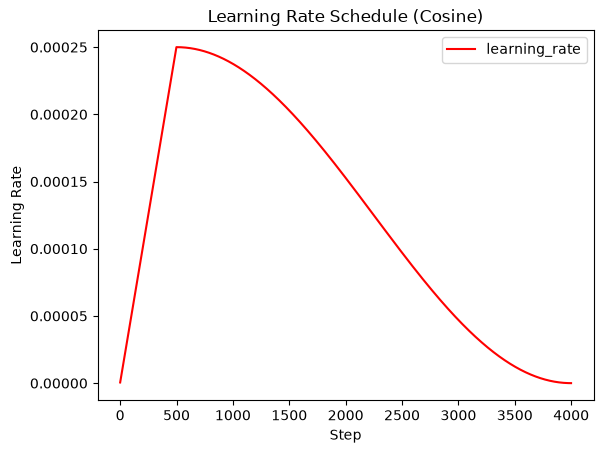

In [40]:
# ---- [탐색] compute lr ----
test_schedule = CosineSchedule(train_steps=4000, warmup_steps=500)
lrs = []
for step_num in range(4000):
    lrs.append(test_schedule.step())

# draw
plt.plot(lrs, 'r-', label='learning_rate')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.legend()
plt.title('Learning Rate Schedule (Cosine)')
plt.show()

---
# [4-3] 파이프라인 — 모델 생성 및 사전학습 (조건 6)

## 모델 생성

`config.n_seq`만 128로 맞춥니다. `n_vocab`과 `i_pad`는 위에서 이미 토크나이저에서
읽어왔으므로 다시 대입하지 않습니다 **[수정 2-3]**.

`summary`로 레이어 구성과 파라미터 수를 확인합니다. 대부분의 파라미터가 임베딩
(8007 × 128 ≈ 100만)에 몰려 있는 것을 볼 수 있습니다.

In [41]:
# 모델 생성
# [수정 2-3] n_vocab / i_pad 는 위 config 생성 시점에 이미 토크나이저에서 읽어왔으므로
#           여기서 다시 대입하지 않습니다. 실제 학습 시퀀스 길이만 128 로 맞춥니다.
#           (전처리 때 make_pretrain_data(..., n_seq=128) 로 만들었으므로 반드시 일치해야 함)
config.n_seq = 128
print("model config:", dict(config))
pre_train_model = build_model_pre_train(config)
pre_train_model.to(device)

summary(pre_train_model, [(10, config.n_seq), (10, config.n_seq)], dtypes=[torch.long, torch.long])

model config: {'d_model': 128, 'n_head': 4, 'd_head': 64, 'dropout': 0.1, 'd_ff': 1024, 'layernorm_epsilon': 0.001, 'n_layer': 3, 'n_seq': 128, 'n_vocab': 8007, 'i_pad': 0}


Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [10, 2]                   --
├─BERT: 1-1                                                  [10, 128]                 --
│    └─SharedEmbedding: 2-1                                  [10, 128, 128]            1,024,896
│    └─PositionEmbedding: 2-2                                [10, 128, 128]            --
│    │    └─Embedding: 3-1                                   [10, 128, 128]            16,384
│    └─Embedding: 2-3                                        [10, 128, 128]            256
│    └─LayerNorm: 2-4                                        [10, 128, 128]            256
│    └─Dropout: 2-5                                          [10, 128, 128]            --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [10, 128, 128]       

## 학습 설정

- **batch_size=64**: GPU 메모리가 부족하면 줄이고, 여유가 있으면 늘립니다.
- **train_steps**: 전체 스텝 수. 스케줄러가 언제까지 감쇠할지 계산하는 데 씁니다.
- **optimizer lr=0.0**: 학습률은 매 스텝 스케줄러가 정하므로 초기값은 의미가 없습니다.
- **`loss_fn_mlm`의 `ignore_index=0`**: 마스킹되지 않은 위치(0)를 loss에서 제외합니다.
  이게 없으면 모델이 "전부 `[PAD]`라고 답하기"만 배우게 됩니다.

### DataLoader **[수정 2-2]**

원래 코드는 memmap 전체를 텐서로 바꿔 GPU에 올렸습니다. 여기서는 `PreTrainDataset`을 써서
배치를 꺼낼 때마다 디스크에서 필요한 만큼만 읽습니다. `num_workers=0`은 윈도우에서
memmap과 멀티프로세싱을 함께 쓸 때 생기는 문제를 피하기 위한 설정입니다.

> **epochs = 10**: 2로 실험해보고 10으로 증가시킴. 더 늘리고 싶지만 시간+vocab+과적합 등의 문제로 10만 하기로 함


In [42]:
epochs = 10
batch_size = 64

# optimizer + learning rate schedule
train_steps = math.ceil(len(pre_train_inputs[0]) / batch_size) * epochs
print("train_steps:", train_steps)
optimizer = optim.Adam(pre_train_model.parameters(), lr=0.0)   # lr 은 스케줄러가 매 step 정한다
learning_rate_scheduler = CosineSchedule(optimizer, train_steps=train_steps, warmup_steps=max(100, train_steps // 10), max_lr=2.5e-4)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss(ignore_index=0)  # 0=[PAD]/비마스크 위치 제외

# [수정 2-2] 원래 코드는 아래 두 줄로 memmap 전체를 텐서화해 GPU 에 올렸습니다.
#   pre_train_inputs = [torch.tensor(np.array(x)).to(device) for x in pre_train_inputs]
#   pre_train_labels = [torch.tensor(np.array(x)).to(device) for x in pre_train_labels]
#   -> memmap 을 쓴 의미가 사라지므로, 배치를 꺼낼 때마다 디스크에서 1건씩 읽는
#      PreTrainDataset 으로 교체합니다. (num_workers=0: 윈도우 + memmap 조합에서 안전)
train_dataset = PreTrainDataset(pre_train_inputs, pre_train_labels)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

pre_train_model.to(device)

history = {
    'nsp_loss': [],
    'mlm_loss': [],
    'nsp_acc': [],
    'mlm_acc': []
}

train_steps: 20000


## 학습 루프

매 배치마다:
1. 데이터를 GPU로 옮기고 **[수정 2-2]**
2. forward로 NSP·MLM logits을 동시에 얻고
3. 두 loss를 **더해서** 한 번에 역전파합니다 — 이것이 두 태스크를 동시에 학습시키는 방식입니다
4. 학습률을 갱신하고 파라미터를 업데이트합니다

**스케줄러 호출 순서** **[수정 3-2]**: 원래는 `optimizer.step()` → `scheduler.step()`
순서였습니다. optimizer를 `lr=0.0`으로 만들어두었기 때문에 그 순서면 **첫 배치가 학습률 0으로
업데이트되어 그냥 버려집니다.** 학습률을 먼저 정하고 그 값으로 갱신하도록 순서를 바꿨습니다.

**accuracy 계산**: NSP는 전체 배치에 대해, MLM은 `mlm_mask`로 **마스킹된 위치만** 평가합니다.
패딩까지 세면 정확도가 99%로 나와 아무 의미가 없어지기 때문입니다.
`clamp(min=1)`은 마스크가 하나도 없는 배치에서 0으로 나누는 것을 막습니다.

> **참고**: 현재는 배치별 accuracy를 단순 평균합니다. 배치마다 마스크 개수가 다르므로
> 엄밀히는 (맞춘 개수 합) / (마스크 개수 합)으로 누적해야 정확합니다.

에폭마다 체크포인트를 저장하므로, 중간에 끊겨도 이어서 쓸 수 있습니다.

In [43]:
for epoch in range(epochs):
    pre_train_model.train()
    total_loss = 0
    total_nsp_loss = 0
    total_mlm_loss = 0
    total_nsp_acc = 0
    total_mlm_acc = 0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch

        # [수정 2-2] 데이터가 CPU(디스크)에서 오므로, 배치 단위로 그때그때 GPU 로 옮깁니다.
        enc_tokens_batch = enc_tokens_batch.to(device)
        segments_batch = segments_batch.to(device)
        labels_nsp_batch = labels_nsp_batch.to(device)
        labels_mlm_batch = labels_mlm_batch.to(device)

        optimizer.zero_grad()

        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

        labels_nsp_batch = labels_nsp_batch.long()
        labels_mlm_batch = labels_mlm_batch.long()

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm_batch.view(-1))

        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        total_loss_batch.backward()
        # [수정 3-2] 원래는 optimizer.step() 다음에 scheduler.step() 을 불렀습니다.
        #   optimizer 를 lr=0.0 으로 만들어 두었기 때문에, 그 순서면 첫 배치가
        #   학습률 0 으로 업데이트되어 그냥 버려집니다.
        #   -> 학습률을 먼저 정하고 그 값으로 파라미터를 갱신하도록 순서를 바꿉니다.
        learning_rate_scheduler.step()  # warmup → cosine 스케줄로 lr 갱신
        optimizer.step()

        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_mask = (labels_mlm_batch != 0)  # 마스킹된 위치만 평가
        mlm_acc = ((logits_mlm.argmax(dim=-1) == labels_mlm_batch) & mlm_mask).float().sum() / mlm_mask.float().sum().clamp(min=1)

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

    # 결과 저장
    history['nsp_loss'].append(total_nsp_loss / len(train_dataloader))
    history['mlm_loss'].append(total_mlm_loss / len(train_dataloader))
    history['nsp_acc'].append(total_nsp_acc / len(train_dataloader))
    history['mlm_acc'].append(total_mlm_acc / len(train_dataloader))

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_dataloader)}, "
          f"NSP Loss: {total_nsp_loss / len(train_dataloader)}, MLM Loss: {total_mlm_loss / len(train_dataloader)}, "
          f"NSP Accuracy: {total_nsp_acc / len(train_dataloader)}, MLM Accuracy: {total_mlm_acc / len(train_dataloader)}")

    # 모델 저장
    torch.save(pre_train_model.state_dict(), f"{MODEL_DIR}/bert_pre_train_epoch_{epoch+1}.pt")

Epoch 1/10 - Loss: 8.337191796064376, NSP Loss: 0.6207780861407518, MLM Loss: 7.716413709402084, NSP Accuracy: 0.5918046875, MLM Accuracy: 0.026960278059530537
Epoch 2/10 - Loss: 7.987093740701676, NSP Loss: 0.5925711073577404, MLM Loss: 7.394522633075714, NSP Accuracy: 0.593625, MLM Accuracy: 0.029521955077536403
Epoch 3/10 - Loss: 7.882116309165955, NSP Loss: 0.5882146164327859, MLM Loss: 7.293901687145233, NSP Accuracy: 0.5968671875, MLM Accuracy: 0.034462911113165316
Epoch 4/10 - Loss: 7.6367338480949405, NSP Loss: 0.583349545866251, MLM Loss: 7.053384302616119, NSP Accuracy: 0.603734375, MLM Accuracy: 0.04605081519950181
Epoch 5/10 - Loss: 7.328473472833633, NSP Loss: 0.5748226402848959, MLM Loss: 6.753650831460953, NSP Accuracy: 0.6161796875, MLM Accuracy: 0.06813957364857197
Epoch 6/10 - Loss: 7.005743147134781, NSP Loss: 0.5664858845472336, MLM Loss: 6.439257262468338, NSP Accuracy: 0.6254609375, MLM Accuracy: 0.09020296612009406
Epoch 7/10 - Loss: 6.656922552585602, NSP Loss: 

## 결과 시각화 (조건 7)

왼쪽은 loss, 오른쪽은 accuracy입니다.

**읽을 때 볼 것:**

- **MLM loss**: `ln(8007) ≈ 9.0`에서 시작해 얼마나 내려갔는가. 어휘가 8000개나 되는
  어려운 문제라 작은 모델로는 크게 떨어지지 않는 것이 정상입니다.
- **NSP loss**: `ln(2) ≈ 0.69`에서 시작합니다. 0.69 근처에 머물면 모델이 사실상
  찍고 있다는 뜻입니다. 이 코드의 NSP negative 샘플이 "같은 chunk를 뒤집은 것"이라
  태스크가 원래 어렵다는 점을 함께 고려해야 합니다.
- **수렴 여부**: 곡선이 평평해졌다면 수렴, 아직 내려가는 중이라면 학습이 부족한 것입니다.

**고찰에 쓸 만한 관점** :

1. **모델 크기와 수렴의 관계** — `d_model=128`, `n_layer=3`은 BERT-Base의 1/6, 1/4
   수준입니다. 표현력이 부족해 loss가 일정 수준 아래로 내려가지 않는 것인지,
   아니면 학습 시간이 부족한 것인지 구분해서 논해보세요.
2. **데이터 양** — 128,000건은 전체 코퍼스의 일부입니다. 사전학습은 보통 수백만~수천만
   스텝을 돌립니다.
3. **두 태스크의 학습 속도 차이** — NSP는 2클래스, MLM은 8007클래스입니다. 난이도가
   달라 수렴 양상도 다릅니다. 두 loss를 단순히 더해서 학습하는 것이 적절한지도 생각해볼 거리입니다.
4. **에폭 수** — 현재 설정으로 관측 가능한 구간이 어디까지인지.
5. **NSP 태스크 설계** — negative 샘플을 "다른 문서에서 가져오기"로 바꾸면 곡선이
   어떻게 달라질지. 수렴하지 않은 원인을 모델 크기 탓으로만 돌리지 않는 것이 중요합니다.

p.s 짜잘한 오류 난 것 같습니다. (3-B 출력창 찐빠)

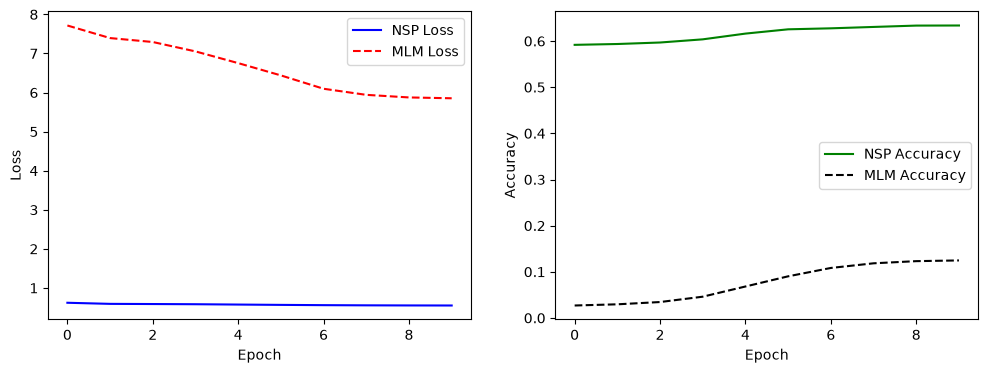

In [44]:
# training result
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['nsp_loss'], 'b-', label='NSP Loss')
plt.plot(history['mlm_loss'], 'r--', label='MLM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['nsp_acc'], 'g-', label='NSP Accuracy')
plt.plot(history['mlm_acc'], 'k--', label='MLM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()